### 9. (a) Visualize attention in RNNs using sentiment analysis. 

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. Toy dataset (5 positive, 5 negative)
data = [
    ("i love this movie", 1),
    ("this film is great", 1),
    ("amazing acting", 1),
    ("wonderful story and cast", 1),
    ("i enjoyed it", 1),
    ("i hate this movie", 0),
    ("worst film ever", 0),
    ("terrible acting", 0),
    ("boring and slow", 0),
    ("i disliked it", 0),
]

# 2. Build vocabulary
vocab = {"<PAD>": 0}
for sentence, _ in data:
    for word in sentence.split():
        if word not in vocab:
            vocab[word] = len(vocab)

# 3. Encode dataset
def encode(sentence):
    return [vocab[word] for word in sentence.split()]

X = [encode(sentence) for sentence, _ in data]
y = [label for _, label in data]

# Pad sequences
max_len = max(len(seq) for seq in X)
X_padded = [seq + [0] * (max_len - len(seq)) for seq in X]

X_tensor = torch.tensor(X_padded)
y_tensor = torch.tensor(y)

# 4. Define RNN with attention
class AttentionRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        embedded = self.embedding(x)                     # [B, T, E]
        output, _ = self.rnn(embedded)                   # [B, T, H]
        attn_weights = torch.softmax(self.attn(output), dim=1)  # [B, T, 1]
        context = torch.sum(attn_weights * output, dim=1)       # [B, H]
        out = self.fc(context)                           # [B, 1]
        return torch.sigmoid(out), attn_weights

# 5. Train the model
model = AttentionRNN(vocab_size=len(vocab), embedding_dim=16, hidden_dim=32)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(30):
    model.train()
    optimizer.zero_grad()
    outputs, _ = model(X_tensor)
    loss = criterion(outputs.squeeze(), y_tensor.float())
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 6. Visualize attention on a test sentence
test_sentence = "i love this movie"
test_input = torch.tensor([encode(test_sentence) + [0] * (max_len - len(encode(test_sentence)))])
model.eval()
with torch.no_grad():
    _, attention_weights = model(test_input)
    attention_weights = attention_weights.squeeze().numpy()

Epoch 5, Loss: 0.5610
Epoch 10, Loss: 0.2651
Epoch 15, Loss: 0.0359
Epoch 20, Loss: 0.0056
Epoch 25, Loss: 0.0016
Epoch 30, Loss: 0.0007


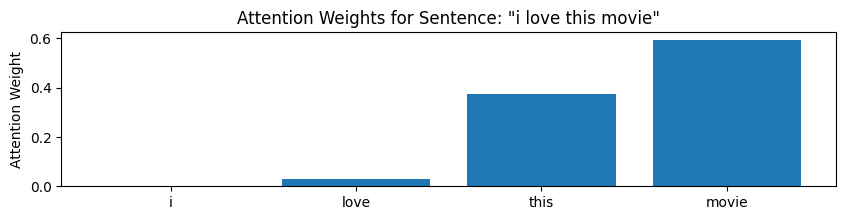

In [6]:
# 7. Plot attention weights
words = test_sentence.split() + ["<PAD>"] * (max_len - len(test_sentence.split()))
plt.figure(figsize=(10, 2))
plt.bar(words, attention_weights[:len(words)])
plt.title("Attention Weights for Sentence: \"i love this movie\"")
plt.ylabel("Attention Weight")
plt.show()